In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter,
#   proximal_promoter, all_variants, all_non_coding
# ============================================================
variant_class = 'missense'

include_all_vars = False  # If True, keep variants without Olink data (impute olink_mean_pheno = 0)
exclude_clinvar = False   # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False      # Independent toggle: include only ClinVar-annotated variants

# Initialize new annotation variable as None
new_anno_local = None
new_anno_df = None

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories'] + ['olink']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  Exclude ClinVar: {exclude_clinvar}")
print(f"  Only ClinVar: {only_clinvar}")
print(f"  Include all vars (impute Olink=0): {include_all_vars}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

# Add Olink as annotation
exp_annos = pl.DataFrame({
    "category": ["olink", "olink"],
    "annotation": ["olink_mean_pheno", "olink_mean_pheno_abs"],
    "color": ["#000000", "#E65100"],
    "label": ["Plasma Olink", "Plasma Olink (abs)"],
    "annotation_dir": [-1, 1],
}).with_columns(pl.col("annotation_dir").cast(pl.Int8))

anno_config_df = pl.concat([anno_config_df, exp_annos], how='vertical')
all_annotation_list = anno_config_df['annotation'].to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Categories: ['missense', 'conservation', 'olink']
  Exclude ClinVar: False
  Only ClinVar: False
  Include all vars (impute Olink=0): False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),

        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

selected_annos = list(set(selected_annos).intersection(set(existing_annos)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_571447/3381428848.py:58: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_571447/3381428848.py:71: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


zooverphylop,verphylop,bayes_del,zoopriphylop,clinpred_score,am_pathogenicity,esmscoremissense,esm1b_llr,id,mamphylop,gpn_score,revel_score,region,cpt1_llr,priphylop,polyphen
f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32,f32,str,f32,f32,f32
0.648,3.942,-0.466288,0.628,0.133098,0.1214,-3.493,0.0,"""chr1:55063472:T:C""",1.399,-3.65,0.058,"""ENSG00000169174""",0.0,0.321,0.018
3.649,3.941,-0.540699,0.999,0.551985,0.0852,-5.821,-6.432,"""chr22:43258222:T:C""",1.805,-4.9,0.067,"""ENSG00000159307""",0.121972,0.469,0.014
3.482,2.519,-0.378917,0.937,0.673255,0.2021,-2.005,-2.519,"""chr1:100723217:G:T""",2.982,-5.35,0.104,"""ENSG00000162692""",0.102354,0.595,0.071
8.787,8.82,0.021352,0.998,0.963567,0.8453,-4.157,-5.819,"""chr19:39473487:G:A""",4.494,-10.89,0.52,"""ENSG00000196235""",0.146373,0.595,0.998
-2.114,0.663,-0.709861,0.971,0.034818,0.0625,-2.699,-2.956,"""chr5:76693399:A:G""",-0.992,0.11,0.137,"""ENSG00000145703""",0.034421,-0.508,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.708,0.115,-0.544942,0.999,0.082661,0.1068,-3.692,-4.066,"""chr3:44841208:A:C""",1.297,-4.78,0.071,"""ENSG00000163808""",0.115931,0.467,0.003
8.903,7.518,0.309983,0.986,0.999639,0.8301,-5.737,-9.881,"""chr3:66383040:C:G""",2.907,-11.28,0.71,"""ENSG00000144749""",0.315277,0.418,1.0
8.872,7.518,0.096229,0.999,0.98067,0.9092,-3.858,-10.261,"""chr12:62501682:C:T""",2.907,-8.94,0.559,"""ENSG00000061987""",0.207261,0.418,0.914


In [5]:
# Add Olink measurements as annotation
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"
OLINK_APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{OLINK_APPV_FILE} -o {LOCAL_APPV_DIR}/{OLINK_APPV_FILE} -f

olink_appv = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{OLINK_APPV_FILE}")
    .filter(pl.col('n_individuals') <= mac)
    .rename({'mean_pheno_value': 'olink_mean_pheno'})
    .with_columns(
        olink_mean_pheno_abs = pl.col('olink_mean_pheno').abs(),
        region = pl.col('phenotype').str.replace(r'_olink', '')
    )
    .filter(
        pl.col('region').is_in(gene_trait_df.select('region').unique().to_series())
    )
    .select(['id', 'region', 'olink_mean_pheno', 'olink_mean_pheno_abs'])
)

olink_regions = olink_appv.select('region').collect().unique()['region'].to_list()

if include_all_vars:
    # Left join: keep all variants, impute missing Olink values to 0
    anno = (
        anno.lazy()
        .filter(pl.col('region').is_in(olink_regions))
        .join(olink_appv, on=['id', 'region'], how='left')
        .with_columns(
            pl.col('olink_mean_pheno').fill_null(0.0),
            pl.col('olink_mean_pheno_abs').fill_null(0.0),
        )
        .collect(engine='streaming')
    )
else:
    # Inner join: only keep variants with Olink measurements
    anno = (
        anno.lazy()
        .join(olink_appv, on=['id', 'region'], how='inner')
        .collect(engine='streaming')
    )

# Update selected_annos to include olink columns
olink_annos = ['olink_mean_pheno', 'olink_mean_pheno_abs']
selected_annos = selected_annos + [a for a in olink_annos if a not in selected_annos]

anno

[===========================================================>] Completed 100,324,032 of 100,324,032 bytes (100%) /home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquetet


/tmp/ipykernel_571447/2075746532.py:22: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_571447/2075746532.py:41: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


zooverphylop,verphylop,bayes_del,zoopriphylop,clinpred_score,am_pathogenicity,esmscoremissense,esm1b_llr,id,mamphylop,gpn_score,revel_score,region,cpt1_llr,priphylop,polyphen,olink_mean_pheno,olink_mean_pheno_abs
f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32,f32,str,f32,f32,f32,f32,f32
3.514,5.626,-0.466193,0.001,0.048619,0.0837,-4.389,-6.905,"""chr16:2112848:T:C""",3.24,-3.62,0.268,"""ENSG00000008710""",0.166106,0.449,0.708,-2.010245,2.010245
4.258,4.86,-0.487175,0.996,0.961354,0.1051,-4.871,-6.563,"""chr17:1635390:G:A""",1.868,-6.11,0.122,"""ENSG00000074660""",0.143864,0.595,0.974,-0.418532,0.418532
2.75,2.055,-0.4455,0.933,0.014344,0.0887,-2.913,-4.224,"""chr4:88046868:G:T""",1.955,-4.92,0.086,"""ENSG00000118762""",0.088597,0.595,0.0,1.699426,1.699426
6.173,8.683,-0.021036,0.999,0.388238,0.0,-7.06,0.0,"""chr2:178733263:A:G""",3.366,-10.13,0.628,"""ENSG00000155657""",0.0,0.475,0.0,0.019137,0.019137
6.543,2.728,-0.164171,0.442,0.728199,0.1754,-3.688,-7.381,"""chr2:237371870:G:C""",2.856,-6.65,0.386,"""ENSG00000163359""",0.205066,0.595,0.0,0.597284,0.597284
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8.861,4.678,-0.603589,0.992,0.71711,0.0,-6.251,0.0,"""chr13:98519272:C:T""",2.846,-9.09,0.097,"""ENSG00000102572""",0.0,0.418,0.024,-0.291591,0.291591
7.017,9.004,0.045231,0.999,0.624869,0.3572,-11.308,-10.206,"""chr9:127093843:G:A""",4.494,-9.07,0.732,"""ENSG00000136859""",0.428841,0.595,0.844,-0.528628,0.528628
-1.095,-1.257,-0.684571,0.077,0.0,0.0,-2.041,0.0,"""chr2:178665728:A:G""",-0.29,-2.11,0.0,"""ENSG00000155657""",0.0,0.475,0.0,0.188621,0.188621


In [6]:
# anno already has olink columns from the inner join in the previous cell
# selected_annos already includes olink annotations from Cell 3 + Cell 4/5

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr16:2112848:T:C""","""ENSG00000008710""","""am_pathogenicity""",0.0837
"""chr17:1635390:G:A""","""ENSG00000074660""","""am_pathogenicity""",0.1051
"""chr4:88046868:G:T""","""ENSG00000118762""","""am_pathogenicity""",0.0887
"""chr2:178733263:A:G""","""ENSG00000155657""","""am_pathogenicity""",0.0
"""chr2:237371870:G:C""","""ENSG00000163359""","""am_pathogenicity""",0.1754
…,…,…,…
"""chr13:98519272:C:T""","""ENSG00000102572""","""olink_mean_pheno_abs""",0.291591
"""chr9:127093843:G:A""","""ENSG00000136859""","""olink_mean_pheno_abs""",0.528628
"""chr2:178665728:A:G""","""ENSG00000155657""","""olink_mean_pheno_abs""",0.188621


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (901, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000174827""","""urate_int""","""olink_mean_pheno_abs""",43,-0.04183,"""#E65100""","""Plasma Olink (abs)""",1,2.3275e-10,-0.029328,0.029328,-1.0,0.04183,1.426283
"""ENSG00000137198""","""mean_corpuscular_haemoglobin_i…","""zooverphylop""",47,0.232503,"""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.037236,0.015916,0.015916,1.0,0.232503,14.607689
"""ENSG00000167601""","""standing_height_int""","""bayes_del""",123,-0.193116,"""#feb72d""","""BayesDel""",1,0.028046,-0.028542,0.028542,-1.0,0.193116,6.76612
"""ENSG00000130340""","""platelet_crit_int""","""gpn_score""",68,-0.061765,"""#942C80""","""GPN-MSA""",-1,0.042051,-0.009899,0.009899,-1.0,-0.061765,-6.239422
"""ENSG00000132855""","""triglycerides_int""","""am_pathogenicity""",40,-0.295122,"""#feb72d""","""AlphaMissense""",1,2.4251e-14,-0.051515,0.051515,-1.0,0.295122,5.728835
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000205758""","""monocyte_count_int""","""zoopriphylop""",33,-0.249759,"""#942C80""","""Zoonomia Primate PhyloP""",1,0.029094,-0.022953,0.022953,-1.0,0.249759,10.881475
"""ENSG00000140564""","""forced_vital_capacity_fvc_int""","""zoopriphylop""",138,-0.085377,"""#942C80""","""Zoonomia Primate PhyloP""",1,0.009837,-0.009677,0.009677,-1.0,0.085377,8.823124
"""ENSG00000138685""","""sitting_height_int""","""olink_mean_pheno_abs""",13,-0.340659,"""#E65100""","""Plasma Olink (abs)""",1,0.000749,-0.023937,0.023937,-1.0,0.340659,14.231411


In [9]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000167601""","""standing_height_int""","""bayes_del""",123,-0.193116,"""#feb72d""","""BayesDel""",1,0.028046,-0.028542,0.028542,-1.0,0.193116,6.76612,16
"""ENSG00000171105""","""apolipoprotein_b_int""","""olink_mean_pheno_abs""",113,-0.00062,"""#E65100""","""Plasma Olink (abs)""",1,0.007933,-0.013223,0.013223,-1.0,0.00062,0.046859,16
"""ENSG00000119681""","""standing_height_int""","""bayes_del""",243,-0.00497,"""#feb72d""","""BayesDel""",1,2.2425e-7,0.026699,0.026699,1.0,-0.00497,-0.186156,16
"""ENSG00000136011""","""igf1_int""","""revel_score""",271,0.039559,"""#feb72d""","""REVEL""",1,0.023578,-0.013375,0.013375,-1.0,-0.039559,-2.957614,16
"""ENSG00000167601""","""standing_height_int""","""zooverphylop""",123,-0.057723,"""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.028046,-0.028542,0.028542,-1.0,0.057723,2.022414,16
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000106804""","""standing_height_int""","""polyphen""",157,-0.066625,"""#feb72d""","""PolyPhen2""",1,0.027637,-0.008391,0.008391,-1.0,0.066625,7.940266,16
"""ENSG00000008710""","""creatinine_int""","""clinpred_score""",824,-0.053033,"""#feb72d""","""ClinPred""",1,2.3819e-47,0.049267,0.049267,1.0,-0.053033,-1.076435,16
"""ENSG00000130559""","""townsend_deprivation_index_at_…","""zooverphylop""",175,-0.14892,"""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.003407,0.024107,0.024107,1.0,-0.14892,-6.177532,16


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


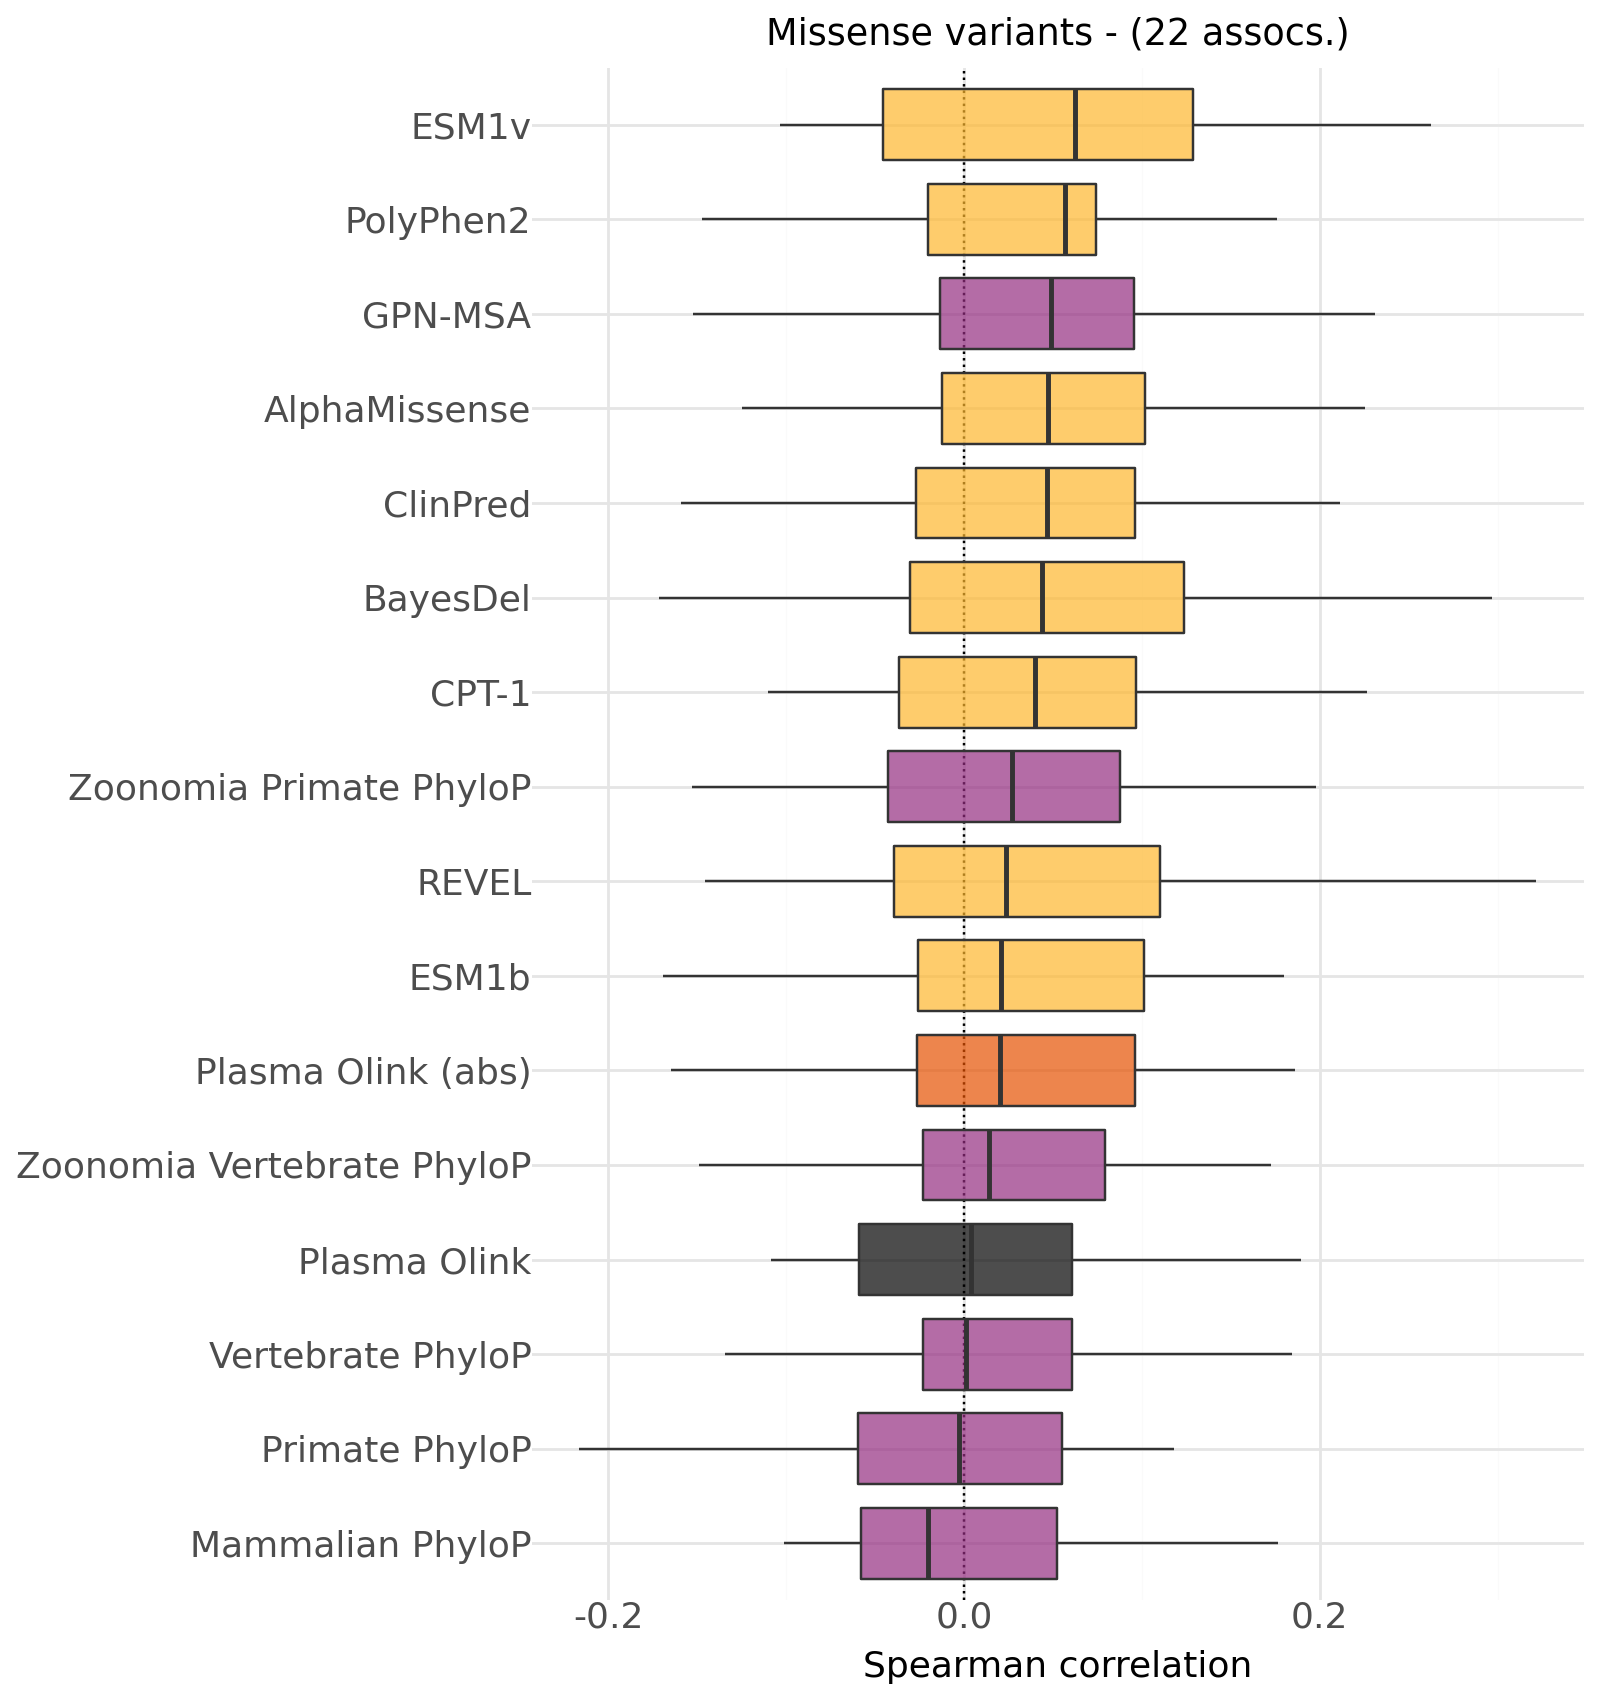

In [11]:
import pandas as pd

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0
if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

# Calculate medians and get ordering (keep as Polars for downstream cells)
plot_corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

ordered_labels = (
    plot_corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
    .to_list()
)

color_dict = dict(plot_corr_pl.select("annotation", "color").unique().iter_rows())

# Convert to pandas for plotting
plot_corr_pd = plot_corr_pl.to_pandas()
plot_corr_pd['label'] = pd.Categorical(plot_corr_pd['label'], categories=ordered_labels, ordered=True)

(
    ggplot(plot_corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{plot_title} variants - ({plot_corr_pl[['region', 'phenotype']].unique().shape[0]} assocs.)"
    )
    + coord_flip()
    + theme(
        figure_size=(8, plot_corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

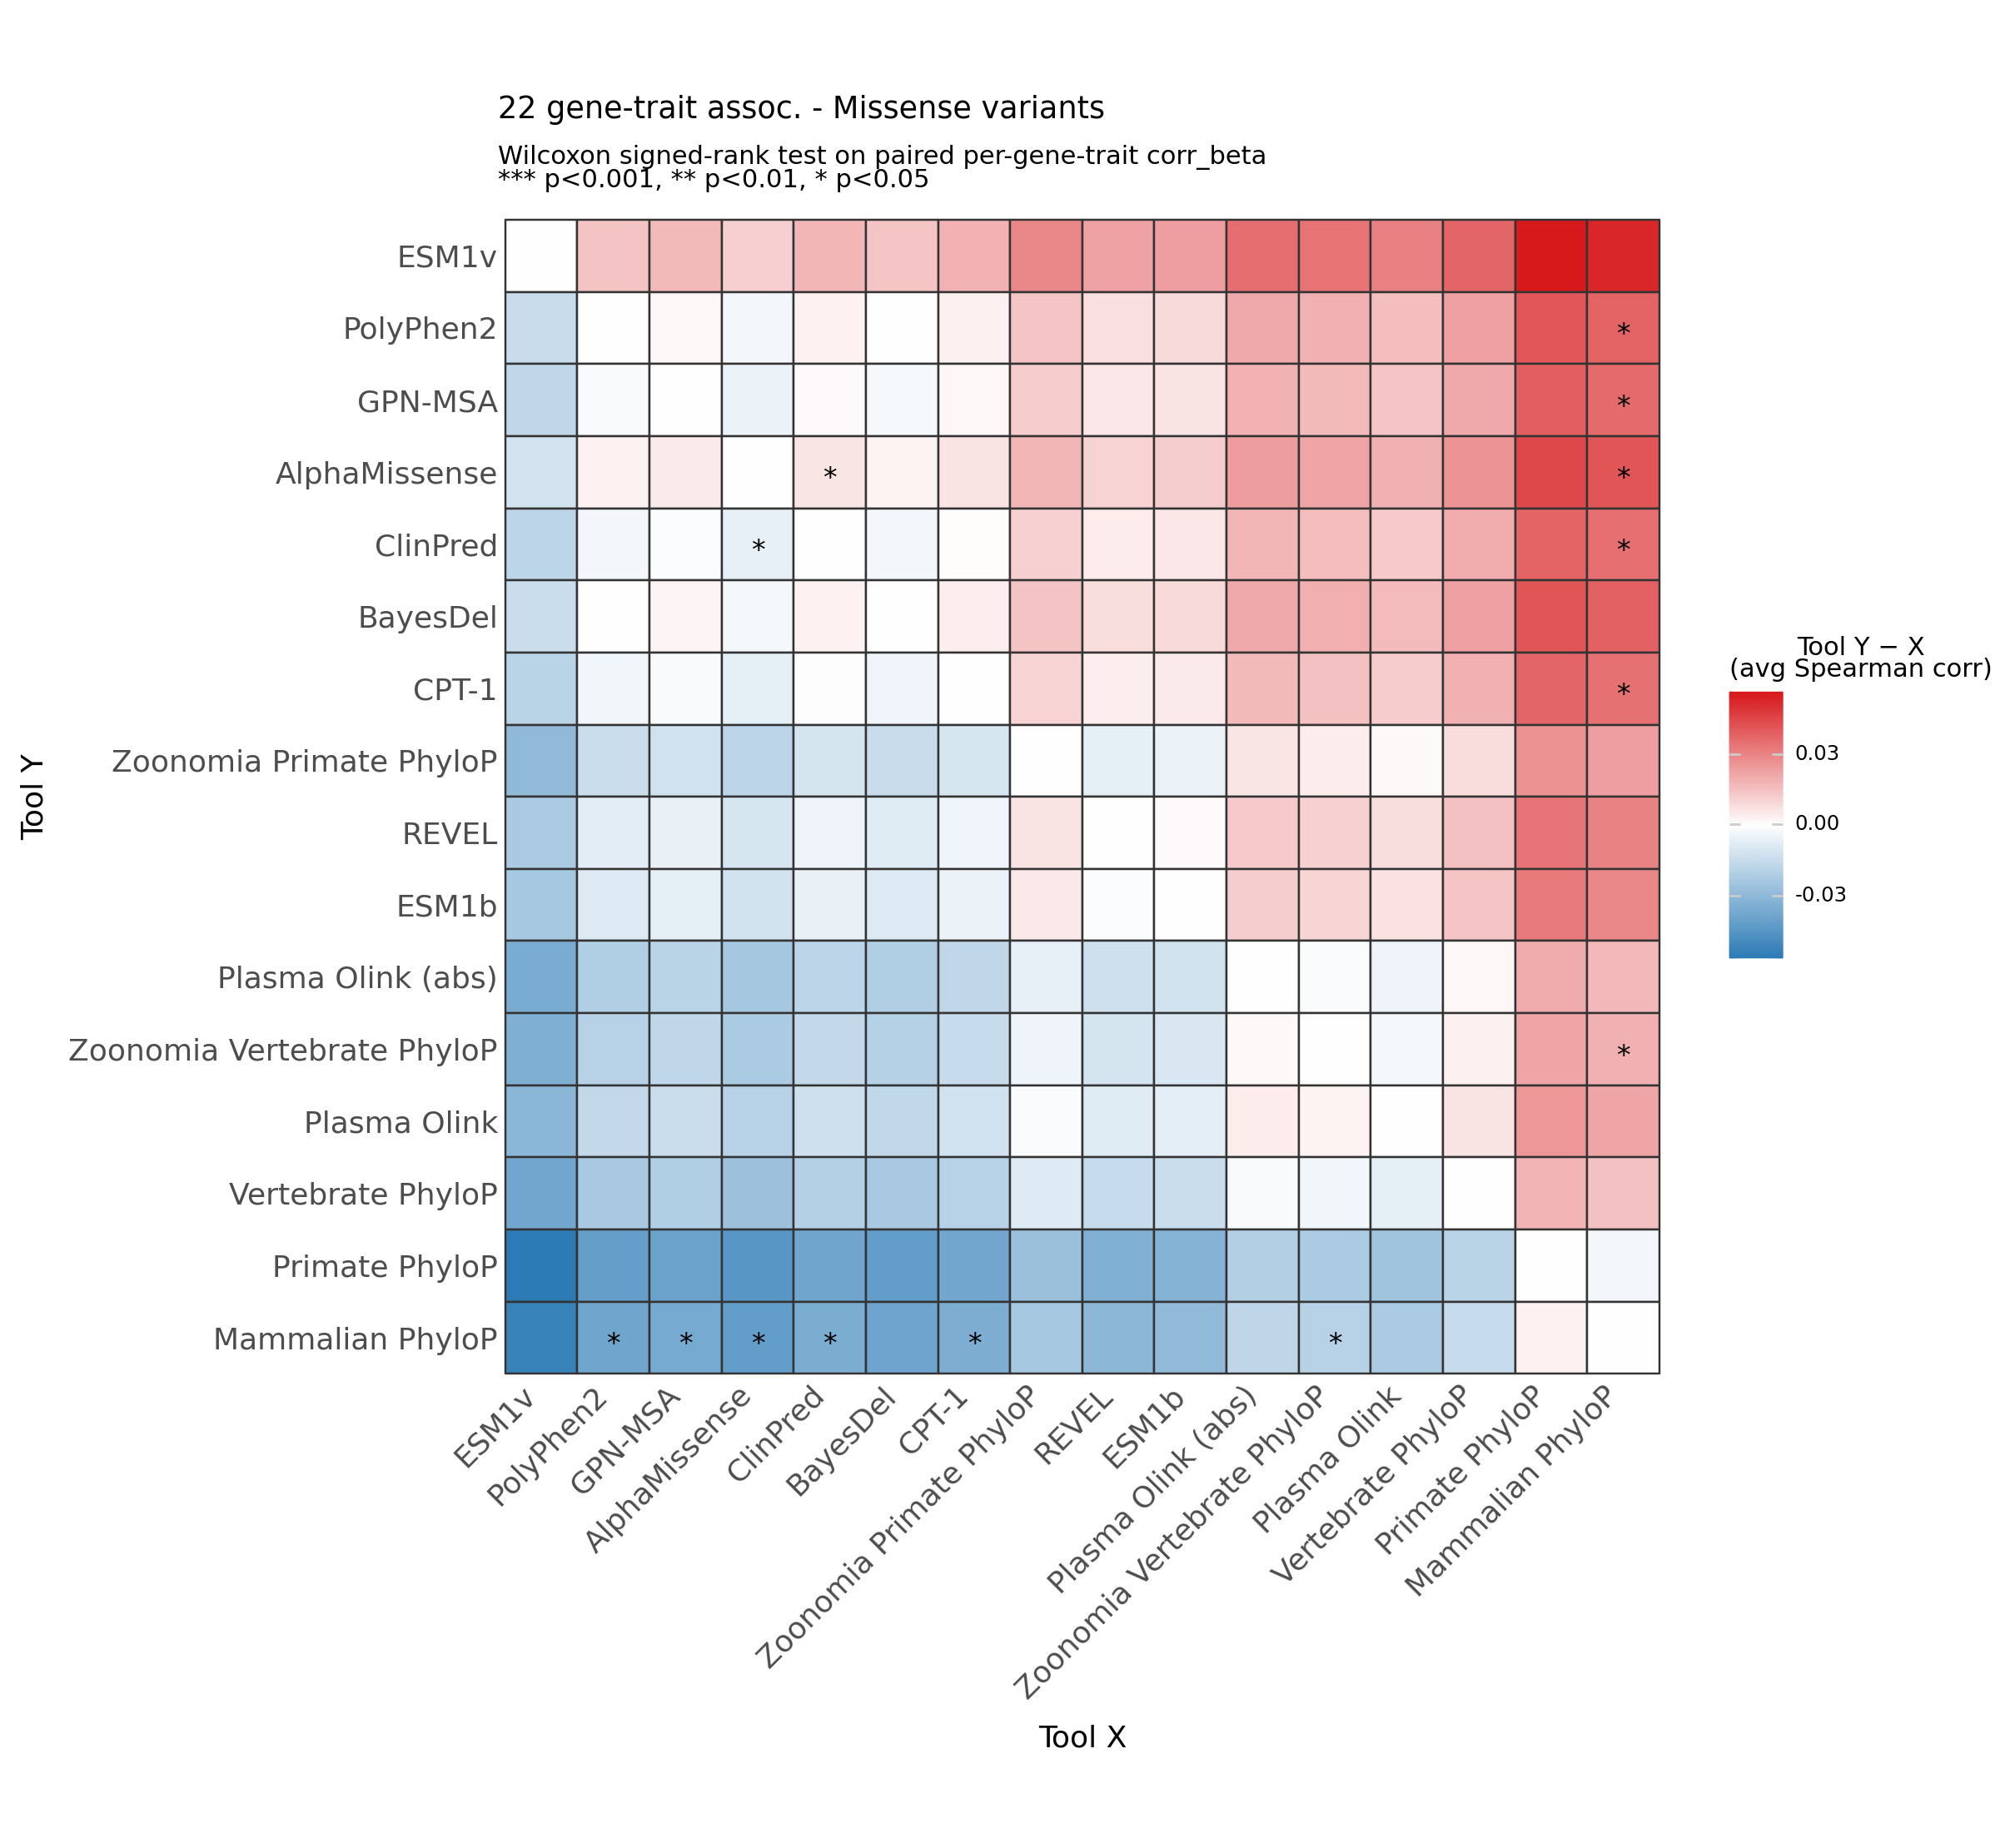

In [12]:
import pandas as pd
import itertools
from scipy import stats

# --- 1. Determine annotation set and ordering ---
plot_annotations = plot_corr_pl.select("annotation").unique().to_series().to_list()

# Build annotation -> label mapping
anno_to_label = dict(
    plot_corr_pl.select(["annotation", "label"]).unique().iter_rows()
)

# Order tools by median corr_beta (best first)
tool_medians = {}
for ann in plot_annotations:
    vals = plot_corr_pl.filter(pl.col("annotation") == ann)["corr_beta"].to_numpy()
    tool_medians[ann] = float(np.nanmedian(vals))

ordered_tools  = sorted(tool_medians.keys(), key=lambda x: tool_medians[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# --- 2. Pairwise Wilcoxon signed-rank test on paired (region, phenotype) corr_beta ---
heatmap_data = []

for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
    label_x = anno_to_label.get(ann_x, ann_x)
    label_y = anno_to_label.get(ann_y, ann_y)

    if ann_x == ann_y:
        heatmap_data.append({
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': 0.0,
            'sig': ''
        })
        continue

    # Inner join on (region, phenotype) to get paired values
    df_x = plot_corr_pl.filter(pl.col("annotation") == ann_x).select(["region", "phenotype", "corr_beta"])
    df_y = plot_corr_pl.filter(pl.col("annotation") == ann_y).select(["region", "phenotype", "corr_beta"])

    paired = df_x.join(df_y, on=["region", "phenotype"], suffix="_y")
    c_x = paired["corr_beta"].to_numpy()
    c_y = paired["corr_beta_y"].to_numpy()

    mean_diff = float(c_y.mean() - c_x.mean())

    if len(c_x) >= 10 and not np.allclose(c_x, c_y):
        _, p_val = stats.wilcoxon(c_x, c_y, alternative='two-sided')
    else:
        p_val = 1.0

    if   p_val < 0.001: sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               sig = ''

    heatmap_data.append({
        'Tool_X': label_x,
        'Tool_Y': label_y,
        'mean_diff': mean_diff,
        'sig': sig
    })

df_heat = pd.DataFrame(heatmap_data)

# Lock in categorical order so best tools appear top/right
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels,       ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_tools = len(ordered_tools)

# --- 3. Plot ---
(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{plot_corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc. - {plot_title} variants",
        subtitle="Wilcoxon signed-rank test on paired per-gene-trait corr_beta\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y \u2212 X\n(avg Spearman corr)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_tools * 0.6 + 2.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13),
        axis_text=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Find gene-trait pairs where olink_score_abs is the top annotation by corr_beta (ties included)

In [ ]:
(
    plot_corr_pl
    .filter(
        (pl.col('annotation')=='olink_mean_pheno_abs') &
        (pl.col('corr_beta')>0)
    )
)

In [73]:
phenotype_groups = ukb_phenotypes = {
    "Anthropometric": [
        "standing_height_int",
        "sitting_height_int",
        "seated_height_int",
        "weight_int",
        "body_mass_index_bmi_int",
        "waist_circumference_int",
        "hip_circumference_int",
        "body_fat_percentage_int",
        "whole_body_water_mass_int",
        "basal_metabolic_rate_int",
        "weight_impedance_int",
        "arm_fat_percentage_left_int",
        "arm_fat_percentage_right_int",
        "arm_fatfree_mass_left_int",
        "arm_fatfree_mass_right_int",
        "arm_predicted_mass_right_int",
        "leg_fat_percentage_left_int",
        "leg_fat_percentage_right_int",
        "leg_fat_mass_left_int",
        "leg_fat_mass_right_int",
        "leg_fatfree_mass_left_int",
        "leg_fatfree_mass_right_int",
        "leg_predicted_mass_left_int",
        "leg_predicted_mass_right_int",
        "trunk_fat_percentage_int",
        "trunk_fat_mass_int",
        "trunk_fatfree_mass_int",
        "trunk_predicted_mass_int",
        "heel_bone_mineral_density_bmd_left_int",
        "heel_bone_mineral_density_bmd_right_int",
        "heel_bone_mineral_density_bmd_tscore_automated_int",
        "heel_bone_mineral_density_bmd_tscore_automated_left_int",
        "heel_bone_mineral_density_bmd_tscore_automated_right_int",
        "forced_vital_capacity_fvc_int",
        "forced_vital_capacity_fvc_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_int",
        "forced_expiratory_volume_in_1second_fev1_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_percentage_int",
        "peak_expiratory_flow_pef_int",
        "pulse_rate_int",
        "pulse_rate_automated_reading_int",
        "systolic_blood_pressure_automated_reading_int",
        "diastolic_blood_pressure_automated_reading_int",
        "stroke_volume_during_pwa_int",
        "position_of_pulse_wave_notch_int",
        "hand_grip_strength_left_int",
        "hand_grip_strength_right_int"
    ],
    "Blood Biochemistry": [
        "cholesterol_int",
        "hdl_cholesterol_int",
        "ldl_direct_int",
        "triglycerides_int",
        "apolipoprotein_a_int",
        "apolipoprotein_b_int",
        "lipoprotein_a_int",
        "albumin_int",
        "total_protein_int",
        "alkaline_phosphatase_int",
        "alanine_aminotransferase_int",
        "aspartate_aminotransferase_int",
        "gamma_glutamyltransferase_int",
        "total_bilirubin_int",
        "direct_bilirubin_int",
        "creatinine_int",
        "cystatin_c_int",
        "urea_int",
        "urate_int",
        "calcium_int",
        "phosphate_int",
        "glucose_int",
        "glycated_haemoglobin_hba1c_int",
        "igf1_int",
        "shbg_int",
        "testosterone_int",
        "vitamin_d_int",
        "creactive_protein_int"
    ],
    "Haematology": [
        "white_blood_cell_leukocyte_count_int",
        "red_blood_cell_erythrocyte_count_int",
        "haemoglobin_concentration_int",
        "haematocrit_percentage_int",
        "mean_corpuscular_volume_int",
        "mean_corpuscular_haemoglobin_int",
        "mean_corpuscular_haemoglobin_concentration_int",
        "red_blood_cell_erythrocyte_distribution_width_int",
        "platelet_count_int",
        "platelet_crit_int",
        "mean_platelet_thrombocyte_volume_int",
        "platelet_distribution_width_int",
        "neutrophill_count_int",
        "lymphocyte_count_int",
        "monocyte_count_int",
        "eosinophill_count_int",
        "basophill_count_int",
        "neutrophill_percentage_int",
        "lymphocyte_percentage_int",
        "monocyte_percentage_int",
        "eosinophill_percentage_int",
        "basophill_percentage_int",
        "reticulocyte_percentage_int",
        "reticulocyte_count_int",
        "mean_reticulocyte_volume_int",
        "mean_sphered_cell_volume_int",
        "immature_reticulocyte_fraction_int",
        "high_light_scatter_reticulocyte_percentage_int",
        "high_light_scatter_reticulocyte_count_int"
    ],
    "Urine Biochemistry": [
        "microalbumin_in_urine_int",
        "creatinine_enzymatic_in_urine_int"
    ],
    "Other": [
        "fluid_intelligence_score_int",
        "mean_time_to_correctly_identify_matches_int",
        "townsend_deprivation_index_at_recruitment_int",
        "age_at_hysterectomy_int",
        "fathers_age_at_death_int",
        "mothers_age_at_death_int",
        "age_started_wearing_glasses_or_contact_lenses_int"
    ]
}

# Reverse lookup helper (phenotype -> group)
pheno_to_group = {ph:grp for grp, phs in phenotype_groups.items() for ph in phs}


pheno_grouping_df = pl.DataFrame({
    'phenotype': [pheno for group in phenotype_groups for pheno in phenotype_groups[group]],
    'phenotype_group': [group for group in phenotype_groups for pheno in phenotype_groups[group]]
})

pheno_grouping_df

phenotype,phenotype_group
str,str
"""standing_height_int""","""Anthropometric"""
"""sitting_height_int""","""Anthropometric"""
"""seated_height_int""","""Anthropometric"""
"""weight_int""","""Anthropometric"""
"""body_mass_index_bmi_int""","""Anthropometric"""
…,…
"""townsend_deprivation_index_at_…","""Other"""
"""age_at_hysterectomy_int""","""Other"""
"""fathers_age_at_death_int""","""Other"""


In [ ]:
corr_pl_pheno_grps = (
    plot_corr_pl
    .filter(pl.col('annotation')=='olink_mean_pheno_abs')
    .join(pheno_grouping_df, on='phenotype', how='left')
)

corr_pl_pheno_grps

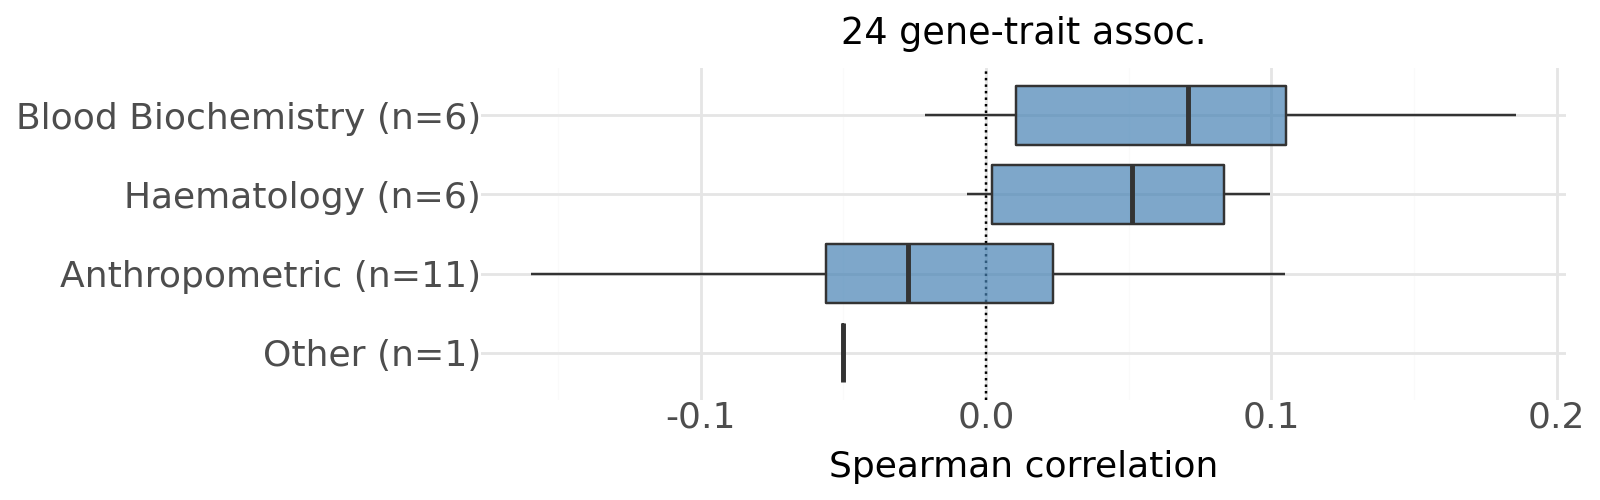

In [77]:
# Calculate median and count per phenotype group using window functions
corr_pl_pheno_grps_with_stats = (
    corr_pl_pheno_grps
    .with_columns([
        pl.col(plotting_col).median().over("phenotype_group").alias("median_corr"),
        pl.len().over("phenotype_group").alias("n")
    ])
)

# Get ordered groups with labels
ordered_groups = (
    corr_pl_pheno_grps_with_stats
    .select(["phenotype_group", "median_corr", "n"])
    .unique()
    .sort("median_corr", descending=False)
    .with_columns(
        label_with_n = pl.concat_str([
            pl.col("phenotype_group"),
            pl.lit(" (n="),
            pl.col("n").cast(pl.Utf8),
            pl.lit(")")
        ])
    )
)

ordered_group_labels = ordered_groups["label_with_n"].to_list()

# Add labels to plot data and apply enum ordering
plot_data = (
    corr_pl_pheno_grps_with_stats
    .join(ordered_groups.select(["phenotype_group", "label_with_n"]), on="phenotype_group")
    .with_columns(pl.col("label_with_n").cast(pl.Enum(ordered_group_labels)))
)

(
    ggplot(plot_data, aes(x="label_with_n", y=plotting_col))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, fill='steelblue', outlier_shape=None)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl_pheno_grps[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, len(ordered_group_labels)/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)